# Task 2 — Vision Transformer (ViT)

In [1]:
!pip install -q transformers timm torchvision matplotlib pillow einops scikit-learn umap-learn

In [2]:
import os, time, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
from transformers import AutoImageProcessor, ViTForImageClassification
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [3]:
# load pretrained ViT and processor
model_name = 'google/vit-base-patch16-224'
processor = AutoImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name).to(device)
try:
    model.set_attn_implementation('eager')
except Exception:
    pass
model.config.output_attentions = True
model.eval()
print('Loaded', model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loaded google/vit-base-patch16-224


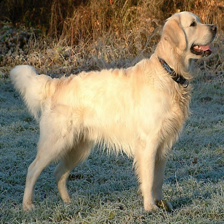

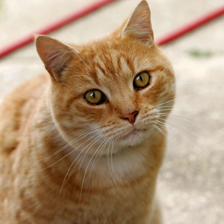

In [4]:
# helper to load images (from URL or local)
import requests
from io import BytesIO
def load_image_from_url(url, timeout=10, max_retries=3):
    "Download an image with basic checks and retries. Returns a PIL.Image in RGB."
    headers = {'User-Agent': 'Mozilla/5.0'}
    last_exc = None
    for attempt in range(max_retries):
        try:
            resp = requests.get(url, headers=headers, timeout=timeout)
        except Exception as e:
            last_exc = e
            time.sleep(1)
            continue
        if resp.status_code != 200:
            last_exc = RuntimeError(f'HTTP {resp.status_code} for {url}')
            time.sleep(1)
            continue
        try:
            img = Image.open(BytesIO(resp.content)).convert('RGB')
            return img
        except Exception as e:
            last_exc = e
            time.sleep(1)
            continue
    raise ValueError(f'Failed to load image from {url}; last error: {last_exc}')

# example images (replace these or upload local files in Colab)
sample_urls = [
    'https://upload.wikimedia.org/wikipedia/commons/b/bd/Golden_Retriever_Dukedestiny01_drvd.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg'
]
images = []
for u in sample_urls:
    try:
        images.append(load_image_from_url(u))
    except Exception as e:
        print('Failed to load', u, '->', e)
if len(images) == 0:
    print('No sample images could be downloaded. In Colab you can upload images via the Files sidebar or use `from google.colab import files; uploaded = files.upload()`')
else:
    for i, img in enumerate(images):
        display(img.resize((224,224)))

In [5]:
# run the images through ViT and show top-1 prediction
def predict_and_probs(imgs, model, processor, device):
    inputs = processor(images=imgs, return_tensors='pt')
    pixel_values = inputs['pixel_values'].to(device)
    with torch.no_grad():
        outputs = model(pixel_values)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    labels = [model.config.id2label[int(p.argmax())] for p in logits]
    return labels, probs
labels, probs = predict_and_probs(images, model, processor, device)
for i, (lab, p) in enumerate(zip(labels, probs)):
    print(f'Image {i}: Top-1 {lab} (p={p.max():.3f})')

Image 0: Top-1 golden retriever (p=0.885)
Image 1: Top-1 tiger cat (p=0.441)


In [6]:
# attention extraction and visualization helpers
import numpy as np
import matplotlib.cm as cm

def get_cls_attention_map(img, model, processor, device, head_agg='mean'):
    "Return CLS->patch attention map upsampled to image size. Attempts to enable eager attentions if needed."
    # ensure model can return attentions; try to set implementation at runtime if available
    try:
        model.set_attn_implementation('eager')
    except Exception:
        pass
    inputs = processor(images=img, return_tensors='pt')
    pixel_values = inputs['pixel_values'].to(device)
    # first forward; if attentions are None we'll try to change implementation and retry
    with torch.no_grad():
        outputs = model(pixel_values, output_attentions=True)
    if getattr(outputs, 'attentions', None) is None:
        # try alternate implementation and retry once
        try:
            model.set_attn_implementation('eager_paged')
        except Exception:
            pass
        with torch.no_grad():
            outputs = model(pixel_values, output_attentions=True)
    if getattr(outputs, 'attentions', None) is None:
        raise RuntimeError('Model did not return attentions. Try upgrading transformers or call model.set_attn_implementation(eager) in this runtime.')
    last_attn = outputs.attentions[-1]  # (batch, num_heads, seq, seq)
    if head_agg == 'mean':
        attn = last_attn.mean(dim=1)  # (batch, seq, seq)
    else:
        attn = last_attn[:, 0:1, :, :].mean(dim=1)
    attn = attn[0]  # (seq_len, seq_len)
    cls_attn = attn[0, 1:]  # (num_patches,)
    num_patches = cls_attn.shape[0]
    grid_size = int(np.sqrt(num_patches))
    cls_map = cls_attn.reshape(grid_size, grid_size).cpu().numpy()
    cls_map = (cls_map - cls_map.min()) / (cls_map.max() - cls_map.min() + 1e-8)
    img_size = processor.size['height'] if 'height' in processor.size else img.size[1]
    cls_img = Image.fromarray((cls_map * 255).astype('uint8')).resize((img_size, img_size), resample=Image.BILINEAR)
    return np.array(cls_img) / 255.0, (grid_size, grid_size)

def overlay_attention(img, att_map, cmap='Reds', alpha=0.5, figsize=(6,6)):
    if isinstance(img, Image.Image):
        img_arr = np.array(img.resize(att_map.shape[::-1]))
    else:
        img_arr = img
    plt.figure(figsize=figsize)
    plt.imshow(img_arr)
    cmap_fn = cm.get_cmap(cmap)
    colored = cmap_fn(att_map)  # HxWx4
    plt.imshow(colored, alpha=alpha)
    plt.axis('off')
    plt.show()

def save_overlay(img, att_map, out_path, cmap='Reds', alpha=0.5):
    if isinstance(img, Image.Image):
        img_arr = np.array(img.resize(att_map.shape[::-1]))
    else:
        img_arr = img
    cmap_fn = cm.get_cmap(cmap)
    colored = (cmap_fn(att_map)[:, :, :3] * 255).astype('uint8')
    overlay = (img_arr * (1 - alpha) + colored * alpha).astype('uint8')
    Image.fromarray(overlay).save(out_path)
    print('Saved overlay to', out_path)

/tmp/ipython-input-208077753.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap(cmap)


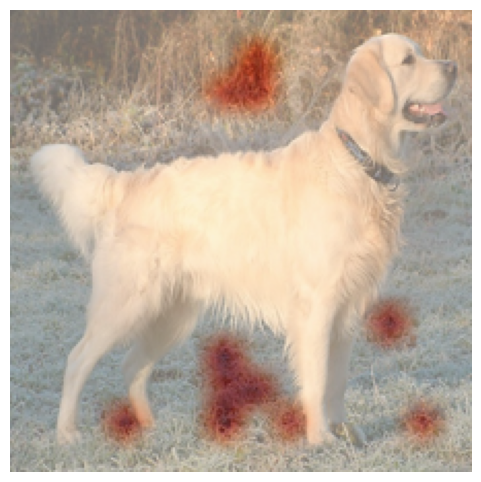

Displayed attention overlay


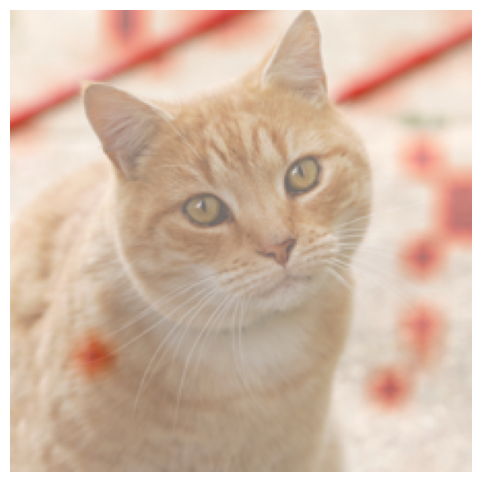

Displayed attention overlay


In [7]:
# compute attention map for first image
if len(images) == 0:
    print('No images available to visualize. Upload or provide image URLs and re-run.')
else:
    for img in images:
      # img = images[0]
      att_map, grid = get_cls_attention_map(img, model, processor, device)
      overlay_attention(img, att_map, alpha=0.45)
      print('Displayed attention overlay')

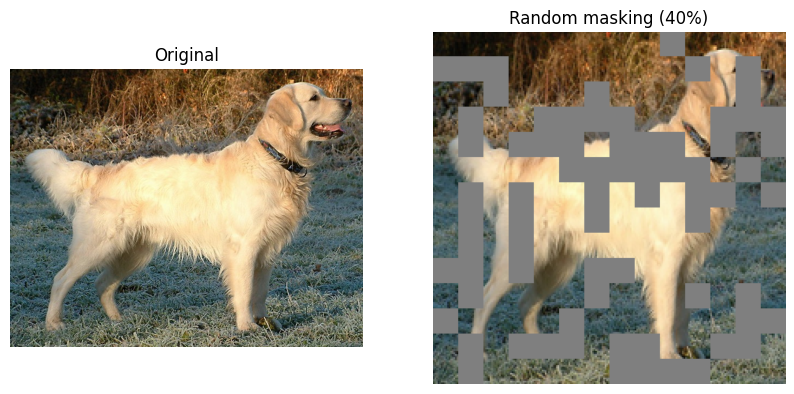

Original top-1: ('golden retriever', np.float32(0.8851187)) — masked agreement: 0.600


In [8]:
# mask patches and evaluate simple robustness metric
from einops import rearrange

def mask_image_patches(img, processor, mask_ratio=0.3, seed=0):
    img_resized = img.resize((processor.size['height'], processor.size['width']))
    w, h = img_resized.size
    patch_size = 16
    gx = w // patch_size
    gy = h // patch_size
    rng = np.random.RandomState(seed)
    mask = rng.rand(gy, gx) < mask_ratio
    arr = np.array(img_resized).copy()
    for i in range(gy):
        for j in range(gx):
            if mask[i,j]:
                y0, x0 = i*patch_size, j*patch_size
                arr[y0:y0+patch_size, x0:x0+patch_size, :] = 127
    return Image.fromarray(arr)

def evaluate_masking(img, model, processor, device, mask_ratio=0.3, trials=3):
    orig_labels, orig_probs = predict_and_probs([img], model, processor, device)
    orig_top = orig_labels[0], orig_probs[0].max()
    accs = []
    for t in range(trials):
        mimg = mask_image_patches(img, processor, mask_ratio=mask_ratio, seed=t)
        labels, probs = predict_and_probs([mimg], model, processor, device)
        accs.append((labels[0] == orig_labels[0]))
    print(f'Original top-1: {orig_top} — masked agreement: {np.mean(accs):.3f}')
    return np.mean(accs)

if len(images) > 0:
    # example of randomly masked image
    masked_example = mask_image_patches(images[0], processor, mask_ratio=0.4, seed=0)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(images[0])
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(masked_example)
    axes[1].set_title('Random masking (40%)')
    axes[1].axis('off')
    plt.show()

    evaluate_masking(images[0], model, processor, device, mask_ratio=0.4, trials=5)

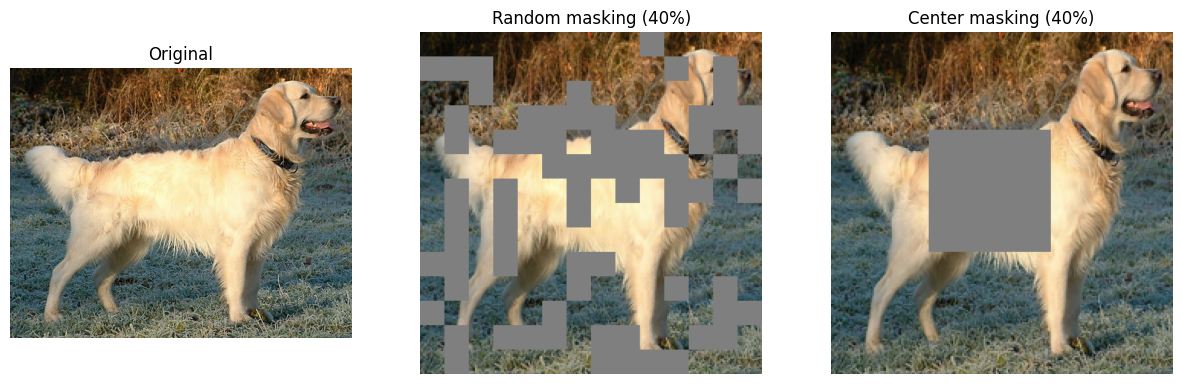

Random masking agreement:
Original top-1: ('golden retriever', np.float32(0.8851187)) — masked agreement: 0.600
Structured (center) masking agreement:
Original top-1: ('golden retriever', np.float32(0.8851187)) — masked agreement: 1.000
Random vs Center agreement: 0.600 vs 1.000


In [ ]:
# structured masking

def mask_center_patches(img, processor, center_ratio=0.4):
    img_resized = img.resize((processor.size['height'], processor.size['width']))
    w, h = img_resized.size
    patch_size = 16
    gx = w // patch_size
    gy = h // patch_size

    block_w = max(1, int(gx * center_ratio))
    block_h = max(1, int(gy * center_ratio))
    start_x = (gx - block_w) // 2
    start_y = (gy - block_h) // 2

    arr = np.array(img_resized).copy()
    for i in range(start_y, start_y + block_h):
        for j in range(start_x, start_x + block_w):
            y0, x0 = i * patch_size, j * patch_size
            arr[y0:y0+patch_size, x0:x0+patch_size, :] = 127
    return Image.fromarray(arr)

def evaluate_masking_fn(img, model, processor, device, mask_fn, trials=3):
    orig_labels, orig_probs = predict_and_probs([img], model, processor, device)
    orig_top = orig_labels[0], orig_probs[0].max()
    accs = []
    for t in range(trials):
        mimg = mask_fn(img, processor, t)
        labels, probs = predict_and_probs([mimg], model, processor, device)
        accs.append((labels[0] == orig_labels[0]))
    print(f'Original top-1: {orig_top} — masked agreement: {np.mean(accs):.3f}')
    return np.mean(accs)

if len(images) > 0:
    random_masked = mask_image_patches(images[0], processor, mask_ratio=0.4, seed=0)
    center_masked = mask_center_patches(images[0], processor, center_ratio=0.4)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(images[0])
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(random_masked)
    axes[1].set_title('Random masking (40%)')
    axes[1].axis('off')
    axes[2].imshow(center_masked)
    axes[2].set_title('Center masking (40%)')
    axes[2].axis('off')
    plt.show()

    print('Random masking agreement:')
    rand_acc = evaluate_masking_fn(
        images[0], model, processor, device,
        mask_fn=lambda im, proc, t: mask_image_patches(im, proc, mask_ratio=0.4, seed=t),
        trials=5
    )
    print('Structured (center) masking agreement:')
    center_acc = evaluate_masking_fn(
        images[0], model, processor, device,
        mask_fn=lambda im, proc, t: mask_center_patches(im, proc, center_ratio=0.4),
        trials=1
    )
    print(f'Random vs Center agreement: {rand_acc:.3f} vs {center_acc:.3f}')

In [ ]:
# linear probe on CIFAR-10 subset (CLS vs mean pooling)
from torchvision import datasets

probe_train_size = 2000
probe_val_size = 500
probe_batch = 32

full_train = datasets.CIFAR10(root='./data', train=True, download=True)
full_val = datasets.CIFAR10(root='./data', train=False, download=True)

train_idx = list(range(probe_train_size))
val_idx = list(range(probe_val_size))

train_subset = torch.utils.data.Subset(full_train, train_idx)
val_subset = torch.utils.data.Subset(full_val, val_idx)

class CIFARCollate:
    def __init__(self, processor):
        self.processor = processor
    def __call__(self, batch):
        imgs, labels = zip(*batch)
        inputs = self.processor(images=list(imgs), return_tensors='pt')
        return inputs['pixel_values'], torch.tensor(labels)

collate = CIFARCollate(processor)
train_loader_probe = torch.utils.data.DataLoader(train_subset, batch_size=probe_batch, shuffle=True, collate_fn=collate)
val_loader_probe = torch.utils.data.DataLoader(val_subset, batch_size=probe_batch, shuffle=False, collate_fn=collate)

# Freeze ViT backbone
for p in model.parameters():
    p.requires_grad = False
model.eval()

hidden = model.config.hidden_size
num_classes = 10
cls_head = nn.Linear(hidden, num_classes).to(device)
mean_head = nn.Linear(hidden, num_classes).to(device)

opt_cls = torch.optim.Adam(cls_head.parameters(), lr=1e-3)
opt_mean = torch.optim.Adam(mean_head.parameters(), lr=1e-3)

loss_fn = nn.CrossEntropyLoss()

@torch.no_grad()
def extract_features(pixel_values):
    outputs = model(pixel_values, output_hidden_states=True)
    last = outputs.hidden_states[-1]  # (B, seq, hidden)
    cls = last[:, 0, :]
    mean = last[:, 1:, :].mean(dim=1)
    return cls, mean

def train_probe(head, optimizer, loader, device):
    head.train()
    total_loss = 0.0
    for pixel_values, labels in loader:
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)
        cls, mean = extract_features(pixel_values)
        feats = cls if head is cls_head else mean
        logits = head(feats)
        loss = loss_fn(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_probe(head, loader, device):
    head.eval()
    correct = 0
    total = 0
    for pixel_values, labels in loader:
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)
        cls, mean = extract_features(pixel_values)
        feats = cls if head is cls_head else mean
        logits = head(feats)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

probe_epochs = 5
for ep in range(1, probe_epochs + 1):
    train_loss_cls = train_probe(cls_head, opt_cls, train_loader_probe, device)
    train_loss_mean = train_probe(mean_head, opt_mean, train_loader_probe, device)
    acc_cls = eval_probe(cls_head, val_loader_probe, device)
    acc_mean = eval_probe(mean_head, val_loader_probe, device)
    print(f'Epoch {ep}: CLS acc={acc_cls:.3f}, Mean acc={acc_mean:.3f}')

100%|██████████| 170M/170M [00:03<00:00, 48.8MB/s]


Epoch 1: CLS acc=0.946, Mean acc=0.944
Epoch 2: CLS acc=0.944, Mean acc=0.938
Epoch 3: CLS acc=0.952, Mean acc=0.942
Epoch 4: CLS acc=0.956, Mean acc=0.948
Epoch 5: CLS acc=0.956, Mean acc=0.948
